In [1]:
# Projet2-Apprentissage Automatique (Machine Learning)
## Dataset: Internship Selection Prediction (Classification)

## 1- Importation des bibliothèques

In [2]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

print("Bibliothèques importées avec succès")

Bibliothèques importées avec succès


## Chargement du dataset

In [3]:
import os

# Téléchargement du dataset depuis Kaggle
path = kagglehub.dataset_download("aiexplorer77/internship-selection-prediction-dataset")

# Chargement du fichier CSV dans un DataFrame Pandas
df = pd.read_csv(os.path.join(path, "Internship_Selection_Dataset.csv"))

print("Fichier chargé : Internship_Selection_Dataset.csv")
print("Dimensions du dataset :", df.shape)
df.head()

100%|██████████| 164k/164k [00:00<00:00, 12.6MB/s]

Extracting files...
Fichier chargé : Internship_Selection_Dataset.csv
Dimensions du dataset : (10000, 21)


,student_id,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,extracurricular,...,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,placement_training,selected
0,1,6.87,7,0,0,4,3,2,7,Yes,...,0,7,5,9,3,1,4,4,Yes,1
1,2,9.75,4,4,2,3,3,6,1,Yes,...,3,2,8,8,3,9,8,5,Yes,1
2,3,8.66,2,1,1,2,1,4,6,Yes,...,4,1,5,2,2,1,3,2,Yes,1
3,4,7.99,5,4,2,8,8,10,8,No,...,1,5,5,9,2,7,10,1,Yes,1
4,5,5.78,3,2,2,4,9,1,7,Yes,...,4,7,3,8,7,8,6,5,Yes,1


## 3- Présentation du Dataset
**Nom :** Internship Selection Prediction Dataset

**LIEN :** https://www.kaggle.com/datasets/aiexplorer77/internship-selection-prediction-dataset

**Description :** Ce dataset contient des informations sur 10000 étudiant candidats à des stage. Il s'agit d'un problème de **classification binaire**.
L'objectif est de prédire si un candidat sera **sélectionné ou non** pour un stage, en fonction de ses caractéristiques académiques et personnelles.
### **Nombre de caractéristiques**: Le dataset contient 19 caractéristiques(features) après suppression de la colonne 'student_id'(dans le nettoyage), plus 1 colonne cible(selected)
**Label :** Colonne 'Selected' (1 = sélectionné, 0 = non sélectionné)
###**Problème identifiés**:
- Colonne 'student_id' inutile pour la prédiction à supprimée.
- 3 colonnes catégorielles(texte) nécessitaient un encodage numérique.
- Déséquilibre des classes: 73.7% des candidats sont sélectionnés(classe 1) contre 26.3% non sélectionnés(classe0). Ce déséquilibre cause des difficultés pour les modèles à détecter la classe minoritaire(classe 0)

In [4]:
# Nombre d'observations et de caractéristiques
print("Nombre d'observations :", df.shape[0])
print("Nombre de caracteristiques :", df.shape[1] - 1) # On exclut la colonne cible(label)
print()

# Type de chaque colonne
print("Types des caract/ristiques :")
print(df.dtypes)
print()

# Aperçu statistique
df.describe(include='all')

Nombre d'observations : 10000
Nombre de caracteristiques : 20

Types des caract/ristiques :
student_id                   int64
CGPA                       float64
skills_score                 int64
projects_count               int64
internships_done             int64
communication_score          int64
aptitude_score               int64
coding_test_score            int64
resume_score                 int64
extracurricular             object
college_tier                object
hackathons_participated      int64
certifications_count         int64
linkedin_activity_score      int64
github_score                 int64
soft_skills_score            int64
interview_score              int64
consistency_score            int64
backlogs                     int64
placement_training          object
selected                     int64
dtype: object



,student_id,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,extracurricular,...,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,placement_training,selected
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000,...,10000.000000,10000.000000,10000.0000,10000.00000,10000.000000,10000.000000,10000.00000,10000.000000,10000,10000.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Yes,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6876,NaN
mean,5000.50000,7.470792,5.480200,2.534300,1.502000,5.562800,5.526600,5.44940,5.572200,NaN,...,2.520500,4.474100,5.5000,5.49650,5.480200,5.469400,5.49130,2.502100,NaN,0.737400
std,2886.89568,1.438135,2.884829,1.690713,1.115043,2.864765,2.861627,2.86532,2.875868,NaN,...,1.699079,2.871124,2.8876,2.88094,2.881708,2.864557,2.88145,1.711341,NaN,0.440069
min,1.00000,5.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.00000,1.000000,NaN,...,0.000000,0.000000,1.0000,1.00000,1.000000,1.000000,1.00000,0.000000,NaN,0.000000
25%,2500.75000,6.230000,3.000000,1.000000,1.000000,3.000000,3.000000,3.00000,3.000000,NaN,...,1.000000,2.000000,3.0000,3.00000,3.000000,3.000000,3.00000,1.000000,NaN,0.000000
50%,5000.50000,7.460000,5.000000,3.000000,2.000000,6.000000,6.000000,5.00000,6.000000,NaN,...,3.000000,4.000000,6.0000,6.00000,5.000000,5.000000,5.00000,3.000000,NaN,1.000000
75%,7500.25000,8.700000,8.000000,4.000000,2.000000,8.000000,8.000000,8.00000,8.000000,NaN,...,4.000000,7.000000,8.0000,8.00000,8.000000,8.000000,8.00000,4.000000,NaN,1.000000


## 4- Nettoyage du Dataset
Quatre techniques de nettoyage ont été appliquées sur le dataset:

1- Suppression de la colonne 'student_id' : cette colonne est un simple identifiant numérique qui n'apporte aucune information utile au modèle de prédiction.

2- Suppression des doublons : vérification et suppression des lignes identiques dans le dataset. Résultat est 0 doublon trouvé, ce qui confirme la qualité des données.

3- Imputation des valeurs manquantes: vérification de toutes les colonnes, resultat 0 valeur manquante trouvée.

4- Encodage des colonne contenaient du texte, elles ont été converties en valeurs numériques avec LabelEncoder.

5- Standardisation (StandardScaler) technique de mise à l'échelle choisie :
   Transforme les données pour avoir une moyenne de 0 et un écart-type de 1.
   Formule : (x - moyenne) / écart-type
   Résultat : valeurs centrées autour de 0 (ex: -1.2, 0.0, +1.2)

In [5]:
df_clean = df.copy()

# Technique 1 : Suppression de la colonne inutile student_id
df_clean = df_clean.drop(columns=["student_id"])
print("Colonne 'student_id' supprim/e (identifiant sans valeur pr/dictive)")

# Technique 2 : Suppression des doublons
avant = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
apres = df_clean.shape[0]
print(f"Doublons supprim/s : {avant - apres} lignes")

# Technique 3 : Imputation des valeurs manquantes
for col in df_clean.columns:
  if df_clean[col].isnull().sum() > 0:
    if df_clean[col].dtype == 'object':
      df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
    else:
      df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print("Valeurs manquantes apr's nettoyage :", df_clean.isnull().sum().sum())

# Technique 4 : Encodage des colonnes texte (object)
le = LabelEncoder()
cols_texte = df_clean.select_dtypes(include='object').columns
for col in cols_texte:
  df_clean[col] = le.fit_transform(df_clean[col])
  print(f"Colonne '{col}' encodee (texte -> nombre)")

print("\n Dataset apres nettoyage :")
print("Nouvelles dimensions :", df_clean.shape)
df_clean.head()

Colonne 'student_id' supprim/e (identifiant sans valeur pr/dictive)
Doublons supprim/s : 0 lignes
Valeurs manquantes apr's nettoyage : 0
Colonne 'extracurricular' encodee (texte -> nombre)
Colonne 'college_tier' encodee (texte -> nombre)
Colonne 'placement_training' encodee (texte -> nombre)

 Dataset apres nettoyage :
Nouvelles dimensions : (10000, 20)


,CGPA,skills_score,projects_count,internships_done,communication_score,aptitude_score,coding_test_score,resume_score,extracurricular,college_tier,hackathons_participated,certifications_count,linkedin_activity_score,github_score,soft_skills_score,interview_score,consistency_score,backlogs,placement_training,selected
0,6.87,7,0,0,4,3,2,7,1,1,0,7,5,9,3,1,4,4,1,1
1,9.75,4,4,2,3,3,6,1,1,1,3,2,8,8,3,9,8,5,1,1
2,8.66,2,1,1,2,1,4,6,1,1,4,1,5,2,2,1,3,2,1,1
3,7.99,5,4,2,8,8,10,8,0,1,1,5,5,9,2,7,10,1,1,1
4,5.78,3,2,2,4,9,1,7,1,2,4,7,3,8,7,8,6,5,1,1


## 5- Préparation des données (X, y, train/test split)

In [6]:
# Séparation des features (X) et de la cible (y)
# On suppose que la dernière colonne est la colonne cible
target_col = df_clean.columns[-1]
X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

print("Colonne cible :", target_col)
print("Features :", list(X.columns))
print("Taille X :", X.shape)

# Normalisation des features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Division en ensembles d'entrainement (80%) et de test (20%)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
print(f"\n Entrainement : {X_train.shape[0]}observations")
print(f"Test : {X_test.shape[0]} observations")

Colonne cible : selected
Features : ['CGPA', 'skills_score', 'projects_count', 'internships_done', 'communication_score', 'aptitude_score', 'coding_test_score', 'resume_score', 'extracurricular', 'college_tier', 'hackathons_participated', 'certifications_count', 'linkedin_activity_score', 'github_score', 'soft_skills_score', 'interview_score', 'consistency_score', 'backlogs', 'placement_training']
Taille X : (10000, 19)

 Entrainement : 8000observations
Test : 2000 observations


## 6- Entrainement des trois algorithmes

Les 3 algorithmes choisis :
- **Arbre de décision (Decision Tree)** : divise les données selon des règles de décision.Paramètres utilisés, random_state=42
- **K plus proches voisins (KNN, k=5)** : classifie selon les k voisins les plus similaires dans les données d'entrainement et en votant à la majorité. Sensible à la normalisation des données, ce qui justifie l'utilisation du StandardScaler en prétraitement. Paramètres utilisés, n_neighbors=5
- **Forêt aléatoire (Random Forest)** : ensemble de 100 arbres de décision. Chaque arbre vote et la décision finale est celle de la majorité pour plus de robustesse. Paramètres utilisés n_estimators=100, random_state=42


In [7]:
modeles = {
    "Arbre de decision": DecisionTreeClassifier(random_state=42),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Forêt aléatoire": RandomForestClassifier(n_estimators=100, random_state=42)
}

resultats = {}

for nom, modele in modeles.items():
  modele.fit(X_train, y_train)
  y_pred = modele.predict(X_test)
  acc = accuracy_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred, average='weighted')
  resultats[nom] = {"Accuracy": acc, "F1-Score":f1, "predictions": y_pred}
  print(f"[{nom}] Accuracy:{acc:.4f} / F1-Score: {f1:.4f}")

[Arbre de decision] Accuracy:0.6095 / F1-Score: 0.6243
[KNN (k=5)] Accuracy:0.7110 / F1-Score: 0.6747
[Forêt aléatoire] Accuracy:0.7625 / F1-Score: 0.6619


## Validation croisée (Cross-Validation, 5folds)
Au lieu de tester une seule fois, on divise en 5 portions et on teste 5 fois, résultat plus fiable.

====== Validation croisée (5-Fold) =====
[Arbre de decision]
Scores par fold : [np.float64(0.612), np.float64(0.6245), np.float64(0.62), np.float64(0.583), np.float64(0.595)]
 Moyenne : 0.6069
 Écart-type : 0.0156
[KNN (k=5)]
Scores par fold : [np.float64(0.679), np.float64(0.6985), np.float64(0.688), np.float64(0.6895), np.float64(0.6935)]
 Moyenne : 0.6897
 Écart-type : 0.0065
[Forêt aléatoire]
Scores par fold : [np.float64(0.7365), np.float64(0.7375), np.float64(0.735), np.float64(0.7345), np.float64(0.7345)]
 Moyenne : 0.7356
 Écart-type : 0.0012


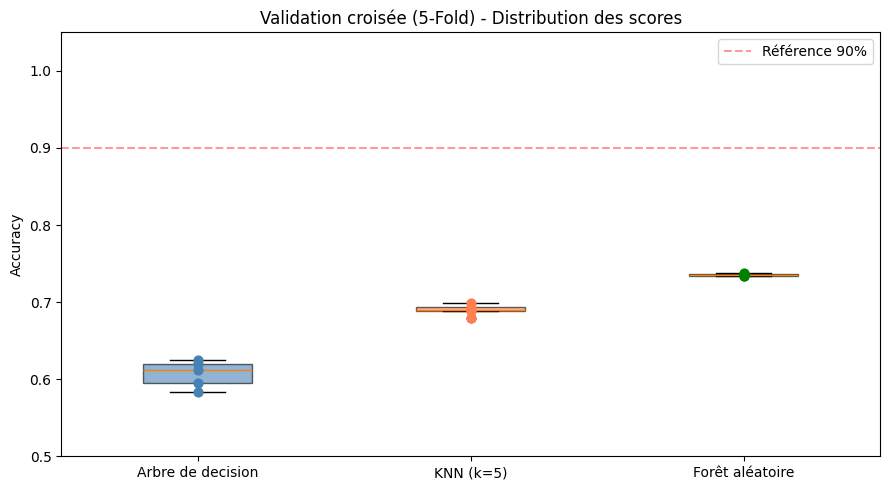

In [8]:
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import numpy as np

print("====== Validation croisée (5-Fold) =====")

cv_resultats = {}

for nom, modele in modeles.items():
  scores = cross_val_score(modele, X_scaled, y, cv=5, scoring='accuracy')
  cv_resultats[nom] = scores
  print(f"[{nom}]")
  print(f"Scores par fold : {[round(s, 4) for s in scores]}")
  print(f" Moyenne : {scores.mean():.4f}")
  print(f" Écart-type : {scores.std():.4f}")

# Visualisation des resultats de cross-validation
fig, ax = plt.subplots(figsize=(9, 5))

positions = np.arange(len(cv_resultats))
noms_cv = list(cv_resultats.keys())
couleurs = ['steelblue', 'coral', 'green']

for i, (nom, scores) in enumerate(cv_resultats.items()):
  ax.boxplot(scores, positions=[i], widths=0.4, patch_artist=True, boxprops=dict(facecolor=couleurs[i], alpha=0.6))
  ax.scatter([i]*5, scores, color=couleurs[i], zorder=5, s=40)

ax.set_xticks(positions)
ax.set_xticklabels(noms_cv)
ax.set_ylabel("Accuracy")
ax.set_title("Validation croisée (5-Fold) - Distribution des scores")
ax.set_ylim(0.5, 1.05)
ax.axhline(y=0.9, color='red', linestyle='--', alpha=0.4, label='Référence 90%')
ax.legend()
plt.tight_layout()
plt.show()



## 7- Visualisation des métriques
Cinq métriques ont été utilisées pour évaluer les modèles :

 1-  Accuracy (exactitude) : Pourcentage de prédictions correctes sur le total des prédictions. Ex : accuracy = 0.7625 signifie que le modèle prédit correctement 76.25% des candidats.

  2-  F1-Score : Moyenne harmonique entre la précision et le rappel. Utile quand les classes sont déséquilibrées car il pénalise les modèles qui ignorent une classe.

  3- Matrice de confusion : Tableau qui montre le nombre de vrais positifs, vrais négatifs, faux positifs et faux négatifs. Permet de voir visuellement où le modèle se trompe.

   4- Rapport de classification : Rapport détaillé avec precision, recall et F1-Score pour chaque classe (0 et 1). Permet d'identifier le problème de détection de la classe minoritaire.

   5- Validation croisée (5-Fold Cross-Validation) : Le dataset est divisé en 5 portions. Le modèle est testé 5 fois sur des portions différentes. La moyenne et l'écart-type des scores mesurent la stabilité et la fiabilité réelle du modèle.

### Métrique 1: Comparaison Accuracy et F1-Score

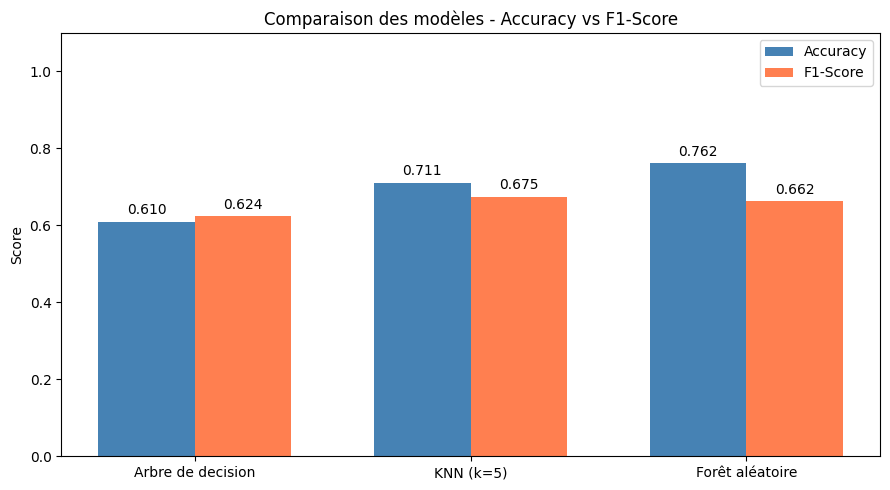

In [9]:
noms = list(resultats.keys())
acc_vals = [resultats[n]["Accuracy"] for n in noms]
f1_vals = [resultats[n]["F1-Score"] for n in noms]

x = np.arange(len(noms))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x-width/2, acc_vals, width, label='Accuracy', color='steelblue')
bars2 = ax.bar(x + width/2, f1_vals, width, label='F1-Score', color='coral')

ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Comparaison des modèles - Accuracy vs F1-Score')
ax.set_xticks(x)
ax.set_xticklabels(noms)
ax.legend()
ax.bar_label(bars1, fmt='%.3f', padding=3)
ax.bar_label(bars2, fmt='%.3f', padding=3)
plt.tight_layout()
plt.show()


### Métrique 2 : Matrices de confusion

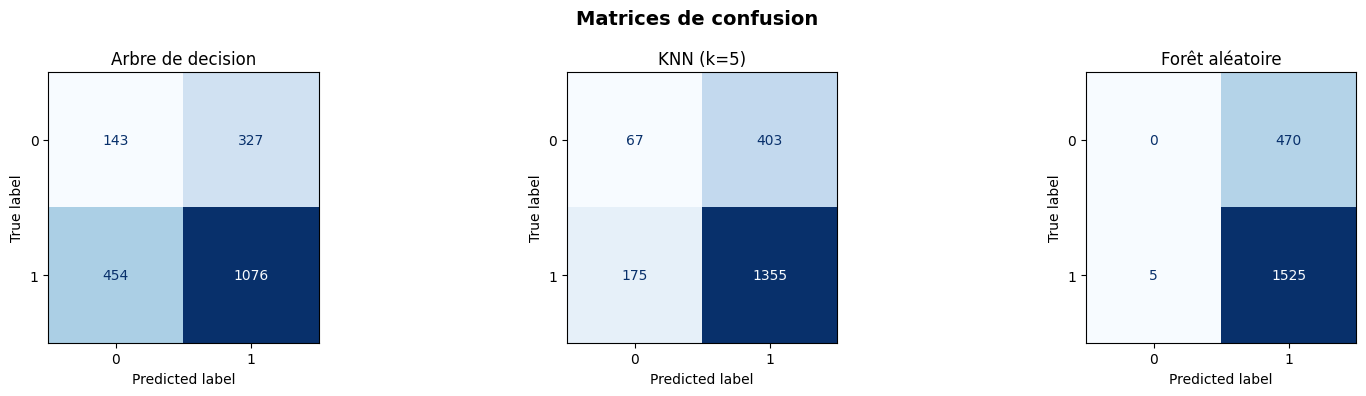

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, nom in zip(axes, noms):
  cm = confusion_matrix(y_test, resultats[nom]["predictions"])
  disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  disp.plot(ax=ax, colorbar=False, cmap='Blues')
  ax.set_title(nom)

plt.suptitle("Matrices de confusion", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Rapport de classification détaillé

In [11]:
for nom in noms:
  print(f"\n{'='*50}")
  print(f"Rapport - {nom}")
  print('='*50)
  print(classification_report(y_test, resultats[nom]["predictions"]))


Rapport - Arbre de decision
              precision    recall  f1-score   support

           0       0.24      0.30      0.27       470
           1       0.77      0.70      0.73      1530

    accuracy                           0.61      2000
   macro avg       0.50      0.50      0.50      2000
weighted avg       0.64      0.61      0.62      2000


Rapport - KNN (k=5)
              precision    recall  f1-score   support

           0       0.28      0.14      0.19       470
           1       0.77      0.89      0.82      1530

    accuracy                           0.71      2000
   macro avg       0.52      0.51      0.51      2000
weighted avg       0.65      0.71      0.67      2000


Rapport - Forêt aléatoire
              precision    recall  f1-score   support

           0       0.00      0.00      0.00       470
           1       0.76      1.00      0.87      1530

    accuracy                           0.76      2000
   macro avg       0.38      0.50      0.43      20

## 8- Analyse et Conclusion

### Tableau récapitulatif

In [12]:
df_resultats = pd.DataFrame({
    "Modele": noms,
    "Accuracy": [round(resultats[n]["Accuracy"], 4) for n in noms],
    "F1-Score": [round(resultats[n]["F1-Score"], 4) for n in noms],
}).set_index("Modele")

df_resultats["Meilleur"] = df_resultats["Accuracy"] == df_resultats["Accuracy"].max()
print(df_resultats.to_string())

meilleur = df_resultats["Accuracy"].idxmax()
print(f"\nMeilleur modele : {meilleur} avec une accuracy de {df_resultats.loc[meilleur, 'Accuracy']:.4f}")

                   Accuracy  F1-Score  Meilleur
Modele                                         
Arbre de decision    0.6095    0.6243     False
KNN (k=5)            0.7110    0.6747     False
Forêt aléatoire      0.7625    0.6619      True

Meilleur modele : Forêt aléatoire avec une accuracy de 0.7625


### Analyse

Dans ce projet, nous avons appliqué trois algorithmes de classification sur le dataset **Internship Selection Prediction** afin de prédire si un candidat sera sélectionné pour un stage.

**Résultats obtenus :**

####|Modele             |Accuracy   |F1-Score     |CV Moyenne   |CV Ecart-type  |
####|Arbre de décision  | 0.6095    |  0.6243     |0.6069       |0.0156         |
####|KNN (k=5)          |0.7110     |0.6747       |0.6897       |0.0065         |
####|**Forêt aléatoire**|**0.7625** |0.6619       |**0.7356**   |**0.0012**     |

#### Meilleur modèle : Forêt aléatoire

La **Forêt aléatoire** est le meilleur modèle avec une accuracy de **76,25%** et une moyenne de cross-validation de **73.56%**. Son écart-type de **0.0012** est le plus faible des trois modèles, ce qui confirme qu'il est très **stable** et fiable peu importe la portion de données utilisée.

#### Analyse par modèle

**Arbre de décision (60.95%)** - Le moins performant. Son écart-type de 0.0156 en cross-validation indique une certaine instabilité. Il souffre probablement d'overfitting : il apprend trop précisément les données d'entrainement et généralise mal sur les nouvelles données.

**KNN k=5 (71.10%)** - Performance intermédiaire. Il obtient le meilleur F1-Score (0.6747), ce qui signifie qu'il est plus équilibré entre la précision et le rappel. Il est stable (écart-type = 0.0065) mais reste moins précis que la Forêt aléatoire.

**Forêt aléatoire (76.25%)** - Meilleure performance globale. En combinant 100 arbres de décision et en faisant voter la majorité, elle réduit le surapprentissage et améliore la généralisation.

#### Problème identifié : déséquilibre des classes

Le dataset présente un déséquilibre important:
- Classe 1 (sélectionné) : **7374 candidats (73.7%)**
- Classe 0 (non sélectionné) : **2626 candidats (26.3%)**

Ce déséquilibre explique pourquoi la Forêt aléatoire prédit presque exclusivement la classe 1 (precision = 0.00 pour la classe 0). Le modèle apprend qu'en prédisant toujours "sélectionné", il atteint déjà 76% d'accuracy sans effort réel.

#### Améliorations possibles
- Utiliser **SMOTE** pour réequilibrer les classes artificiellement
- Optimiser les hyperparamètres avec **GridSearchCV**
- Tester d'autres algorithmes comme **SVM** ou **XGBoost**

## 9- Amélioration 1 - SMOTE (Rééquilibrage des classes)

**Problème :** Le dataset est déséquilibré (73.7% sélectionnés vs 26.3% non sélectionnés).
**Solution :** SMOTE crée des exemples synthétiques de la classe minoritaire pour équilibrer les données.

In [13]:
from imblearn.over_sampling import SMOTE

# Avant SMOTE
print("===Avant SMOTE===")
print(f"Classe 0 (non sélectionné) : {sum(y_train == 0)} ({sum(y_train == 0)/len(y_train)*100:.1f}%)")
print(f"Classe 1 (sélectionné) : {sum(y_train == 1)} ({sum(y_train == 1)/len(y_train)*100:.1f}%)")

# Application de SMOTE sur les données d'entrainement seulement
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

# Après SMOTE
print("\n===Après SMOTE===")
print(f"Classe 0 (non sélectionné) : {sum(y_train_sm == 0)} ({sum(y_train_sm == 0)/len(y_train_sm)*100:.1f}%)")
print(f"Classe 1 (sélectionné) : {sum(y_train_sm == 1)} ({sum(y_train_sm == 1)/len(y_train_sm)*100:.1f}%)")
print(f"\nTaille du train avant : {len(y_train)}")
print(f"Taille du train après : {len(y_train_sm)}")


===Avant SMOTE===
Classe 0 (non sélectionné) : 2156 (27.0%)
Classe 1 (sélectionné) : 5844 (73.0%)

===Après SMOTE===
Classe 0 (non sélectionné) : 5844 (50.0%)
Classe 1 (sélectionné) : 5844 (50.0%)

Taille du train avant : 8000
Taille du train après : 11688


In [14]:
# Entrainement des modèles avec les données SMOTE
print("===Résultats avec SMOTE ===\n")

resultats_smote = {}

for nom, modele in modeles.items():
  modele.fit(X_train_sm, y_train_sm)  # entraine sur donn/es /quilibr/es
  y_pred_sm = modele.predict(X_test)  # teste sur donn/es r/elles
  acc = accuracy_score(y_test, y_pred_sm)
  f1 = f1_score(y_test, y_pred_sm, average='weighted')
  resultats_smote[nom] = {"Accuracy": acc, "F1-Score": f1, "predictions": y_pred_sm}
  print(f"[{nom}] Accuracy: {acc:.4f} | F1-Score: {f1:.4f}")

# Comparaison avant/apr's SMOTE
print("\n=== Comparaison avant/après SMOTE ===")
print(f"{'Modèle':<22} {'Accuracy Avant':>15} {'Accuracy Après':>15}{'Différence':>12}")
print("-"*65)
for nom in noms:
  avant = resultats[nom]["Accuracy"]
  apres = resultats_smote[nom]["Accuracy"]
  diff = apres - avant
  signe = "+" if diff >= 0 else ""
  print(f"{nom:<22} {avant:>15.4f} {apres:>15.4f} {signe+str(round(diff,4)):>12}")


===Résultats avec SMOTE ===

[Arbre de decision] Accuracy: 0.6030 | F1-Score: 0.6217
[KNN (k=5)] Accuracy: 0.4840 | F1-Score: 0.5211
[Forêt aléatoire] Accuracy: 0.7530 | F1-Score: 0.6743

=== Comparaison avant/après SMOTE ===
Modèle                  Accuracy Avant  Accuracy Après  Différence
-----------------------------------------------------------------
Arbre de decision               0.6095          0.6030      -0.0065
KNN (k=5)                       0.7110          0.4840       -0.227
Forêt aléatoire                 0.7625          0.7530      -0.0095


In [15]:
# Rapport de classification après SMOTE - vérifie si classe 0 est mieux détectée
for nom in noms:
  print(f"\n{'='*50}")
  print(f"Rapport SMOTE - {nom}")
  print('='*50)
  print(classification_report(y_test, resultats_smote[nom]["predictions"]))


Rapport SMOTE - Arbre de decision
              precision    recall  f1-score   support

           0       0.25      0.34      0.28       470
           1       0.77      0.68      0.73      1530

    accuracy                           0.60      2000
   macro avg       0.51      0.51      0.50      2000
weighted avg       0.65      0.60      0.62      2000


Rapport SMOTE - KNN (k=5)
              precision    recall  f1-score   support

           0       0.24      0.56      0.34       470
           1       0.77      0.46      0.58      1530

    accuracy                           0.48      2000
   macro avg       0.51      0.51      0.46      2000
weighted avg       0.65      0.48      0.52      2000


Rapport SMOTE - Forêt aléatoire
              precision    recall  f1-score   support

           0       0.32      0.04      0.08       470
           1       0.77      0.97      0.86      1530

    accuracy                           0.75      2000
   macro avg       0.54      0.51

## 10- Amélioration 2 - GridSearchCV (Optimisation des hyperparamètres)

**Problème :** Les paramètres de nos modèles étaient choisis par défaut (ex:'n_estimators=100').

**Solution :** GridSearchCV teste automatiquement plusieurs combinaisons et garde la meilleure.

In [16]:
from sklearn.model_selection import GridSearchCV

# Grilles de paramètres à tester pour chaque modèle
grilles ={
    "Arbre de decision": {
        "modele": DecisionTreeClassifier(random_state=42),
        "params": {
            "max_depth": [5, 10, 20, None],
            "min_samples_split": [2, 5, 10],
            "criterion": ["gini", "entropy"]
        }
    },
    "KNN (k=5)": {
        "modele": KNeighborsClassifier(),
        "params": {
            "n_neighbors": [3, 5, 7, 11],
            "weights": ["uniform", "distance"],
            "metric": ["euclidean", "manhattan"]
        }
    },
    "Forêt aléatoire": {
        "modele": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [50, 100, 200],
            "max_depth": [10, 20, None],
            "max_features": ["sqrt", "log2"]
        }
    }
}

# Recherche des meilleurs paramètres
print("Recherche en cours...\n")

meilleurs_modeles = {}

for nom, config in grilles.items():
  grid = GridSearchCV(
      estimator = config["modele"],
      param_grid = config["params"],
      cv = 5,
      scoring = "accuracy",
      n_jobs = -1 # utilise tous les processeurs disponibles
  )
  grid.fit(X_train, y_train)

  y_pred_grid = grid.predict(X_test)
  acc = accuracy_score(y_test, y_pred_grid)
  f1 = f1_score(y_test, y_pred_grid, average='weighted')

  meilleurs_modeles[nom] = {
      "Accuracy": acc, "F1-Score":f1,
      "predictions": y_pred_grid,
      "meilleurs_params": grid.best_params_
  }

  print(f"[{nom}]")
  print(f" Meilleur parametres: {grid.best_params_}")
  print(f" Accuracy : {acc:.4f} | F1-Score : {f1:.4f}\n")

Recherche en cours...

[Arbre de decision]
 Meilleur parametres: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 2}
 Accuracy : 0.7635 | F1-Score : 0.6652

[KNN (k=5)]
 Meilleur parametres: {'metric': 'euclidean', 'n_neighbors': 11, 'weights': 'uniform'}
 Accuracy : 0.7420 | F1-Score : 0.6729

[Forêt aléatoire]
 Meilleur parametres: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 200}
 Accuracy : 0.7645 | F1-Score : 0.6638



=== Comparaison avant/apres GridSearchCV ===

Modele                  Accuracy Avant  Accuracy Apres   Difference
-----------------------------------------------------------------
Arbre de decision               0.6095         0.7635      +0.154


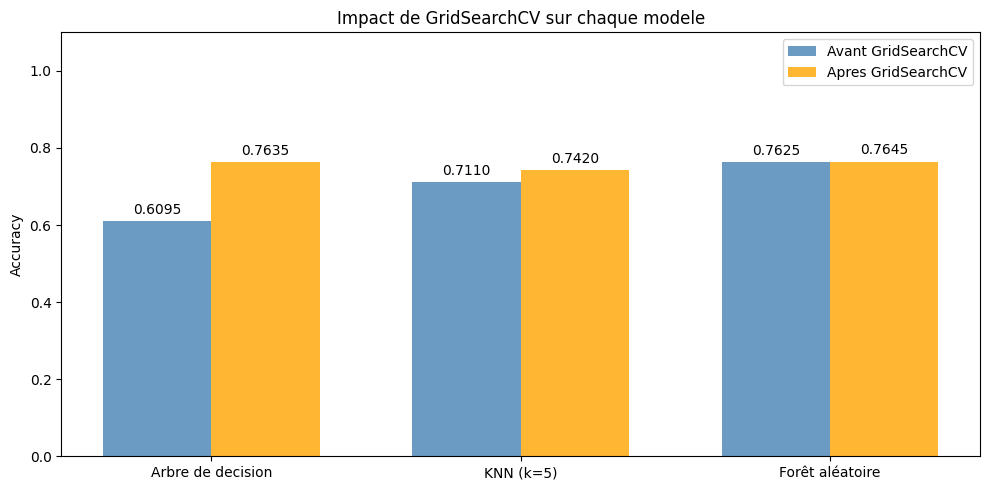

KNN (k=5)                       0.7110         0.7420      +0.031


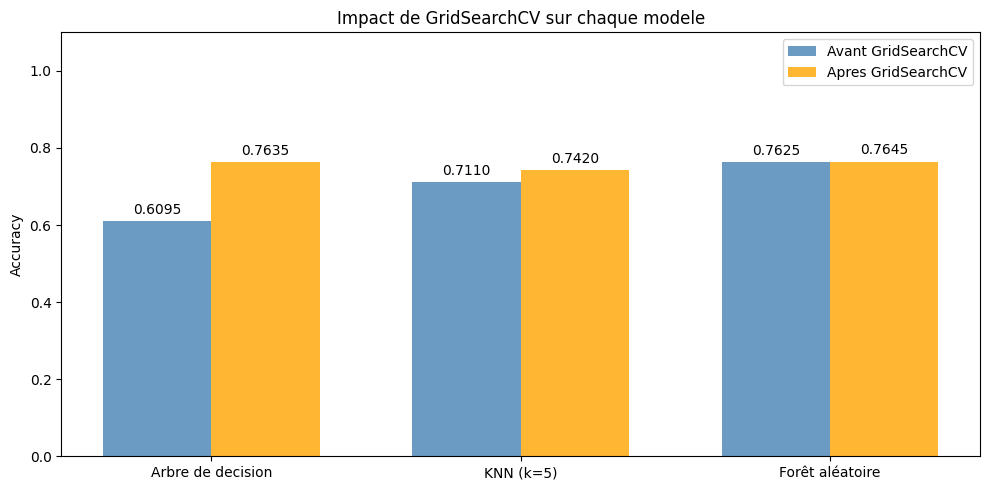

Forêt aléatoire                 0.7625         0.7645      +0.002


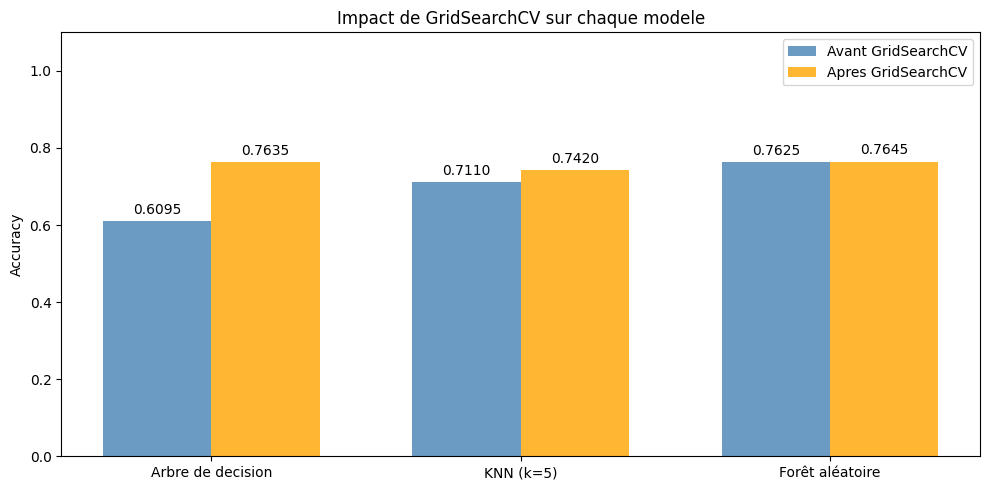

In [17]:
# Comparaison avant/apres GridSearchCV
print("=== Comparaison avant/apres GridSearchCV ===\n")
print(f"{'Modele':<22} {'Accuracy Avant':>15} {'Accuracy Apres':>15} {'Difference':>12}")
print("-"*65)
for nom in meilleurs_modeles.keys():
  avant = resultats[nom]["Accuracy"]
  apres = meilleurs_modeles[nom]["Accuracy"]
  diff = apres - avant
  signe = "+" if diff >= 0 else ""
  print(f"{nom:<22} {avant:>15.4f}{apres:>15.4f}{signe+str(round(diff,4)):>12}")

  # Visualisation
  noms_grid = list(meilleurs_modeles.keys())
  fig, ax = plt.subplots(figsize=(10, 5))
  x = np.arange(len(noms_grid))
  width = 0.35

  b1 = ax.bar(x - width/2, [resultats[n]["Accuracy"] for n in noms_grid],
              width, label='Avant GridSearchCV', color='steelblue', alpha=0.8 )
  b2 = ax.bar(x + width/2, [meilleurs_modeles[n]["Accuracy"] for n in noms_grid],
              width, label='Apres GridSearchCV', color='orange', alpha=0.8 )

  ax.set_ylim(0, 1.1)
  ax.set_ylabel('Accuracy')
  ax.set_title('Impact de GridSearchCV sur chaque modele')
  ax.set_xticks(x)
  ax.set_xticklabels(noms_grid)
  ax.legend()
  ax.bar_label(b1, fmt='%.4f', padding=3)
  ax.bar_label(b2, fmt='%.4f', padding=3)
  plt.tight_layout()
  plt.show()




### Conclusion

#### **Résultats de base sans amélioration**

####|Modele            |Accuracy |F1-Score |CV Moyenne |CV Ecart-type |
####|Arbre de décision | 0.6095  | 0.6243  |0.6069     |0.0156        |
####|KNN (k=5)         |0.7110   |0.6747   |0.6897     |0.0065        |
####|Forêt aléatoire   |0.7625   |0.6619   |0.7356     |0.0012        |

#### **Amélioration 1: SMOTE(Rééquilibrage des classes)**

Le dataset présentait un déséquilibre important:
- Classe 1(sélectionné): **73%** des données.
- Classe 0(non sélectionné): **27%** des données.

SMOTE a crée des exemples synthétiques pour équilibrer les classes à **50/50** (taille du train : de 8000 à 11688).

####|Modele            |Avant SMOTE |Après SMOTE |Différence |
####|Arbre de décision | 0.6095     | 0.6030     |-0.0065    |        
####|KNN (k=5)         |0.7110      |0.4840      |-0.227     |      
####|Forêt aléatoire   |0.7625      |0.7530      |-0.0095    |

**Observation :** SMOTE a légèrement réduit l'accuracy globale mais a amélioré la détection de la classe 0 (recall : de 0.00 à 0.34 - 0.56). Le KNN est très affecté car il est sensible aux distances avec des données synthétiques. La Forêt aléatoire résiste mieux grâce à sa robustesse.

#### **Amélioration 2: GridSearchCV(Optimisation des hyperparamètres)**

GridSearchCV a testé plusieurs combinaisons de paramètres pour chaque modèle et a retenu la meilleure.

####|Modele            |Avant   |Après     |Différence |Meilleurs paramètres      |
####|Arbre de décision | 0.6095 |**0.7635**|**+0.154** |max_depth=5,criterion=gini |
####|KNN (k=5)         |0.7110  |0.7420    |+0.031     |n_neighbors=11, euclidean |
####|Forêt aléatoire   |0.7625  |**0.7645**|+0.002     |n_estimators=200, sqrt    |

**Observation :** GridSearchCV a amélioré tous les modèles. L'Arbre de décision est le grand gagnant avec **+15.4%** grâce au paramètre 'max_depth=5' qui limite l'overfitting. La Forêt aléatoire était déja bien configurée , d'ou une amélioration minimale(+0.2%).

#### **Classement final après GridSearchCV**

####|Modele            |Accuracy finale|   
####|Forêt aléatoire   |0.7645         |
####|Arbre de décision | 0.7635        |
###|KNN (k=5)         |0.7420         |

Grâce à GridSearchCV, l'Arbre de décision est passé de la 3ème à la 2ème place, dépassant le KNN.

#### **Meilleur modèle global :** Forêt aléatoire

La **Forêt aléatoire** reste le meilleur modèle avec une accuracy de **76.45%** après optimisation. En combinant 200 arbres de décision ('n_estimators=200') avec une sélection aléatoire de features ('max_features='sqrt''), elle réduit l'overfitting et généralise bien sur de nouvelles données. Sa cross-validation confirme sa stabilité avec un écart-type de seulement **0.0012**.

#### **Limites et améliorations possibles**
- **Déséquilibre des classes**: malgré SMOTE, la Forêt aléatoire ignore encore la classe 0. une technique plus avancée comme SMOTE + Tomek Links pourrait mieux fonctionner.
- **Autres algorithmes**: SVM ou XGBoost pourraient donner de meilleurs résultats sur ce dataset.
- **Seuil de décision**: ajuster le seuil de probabilité(ex: 0.4 au lieu de 0.5) pour mieux détecter la classe minoritaire.